In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproductibilité
np.random.seed(42)
N = 2883

# Plans tarifaires Fatura
plans      = ["Starter", "Pro", "Business"]
plan_proba = [0.55, 0.30, 0.15]
arpu_map   = {"Starter": 29, "Pro": 79, "Business": 149}

plan       = np.random.choice(plans, size=N, p=plan_proba)
arpu       = np.round(np.array([arpu_map[p] for p in plan]) *
             np.random.uniform(0.90, 1.10, size=N), 2)

anciennete_map = {"Starter":(4,3), "Pro":(8,5), "Business":(14,6)}
anciennete = np.array([
    max(1, int(np.random.normal(anciennete_map[p][0], anciennete_map[p][1])))
    for p in plan])

logins_mois        = np.random.poisson(lam=12, size=N)
features_utilisees = np.random.randint(1, 11, size=N)
tickets_support    = np.random.poisson(lam=1.2, size=N)
nps_score          = np.random.randint(0, 11, size=N)

churn_base_map = {"Starter":0.035, "Pro":0.020, "Business":0.008}
churn_proba    = np.array([churn_base_map[p] for p in plan])
churn_proba   += np.where(logins_mois < 5,     +0.04, 0)
churn_proba   += np.where(logins_mois > 20,    -0.02, 0)
churn_proba   += np.where(tickets_support > 3, +0.04, 0)
churn_proba   += np.where(nps_score < 4,       +0.04, 0)
churn_proba   += np.where(nps_score > 8,       -0.02, 0)
churn_proba   += np.where(anciennete < 2,      +0.03, 0)
churn_proba   += np.where(anciennete > 12,     -0.01, 0)
churn_proba    = np.clip(churn_proba, 0.005, 0.50)
churn          = np.random.binomial(n=1, p=churn_proba)

df = pd.DataFrame({
    "client_id":          [f"CLI-{str(i+1).zfill(4)}" for i in range(N)],
    "plan":               plan,
    "arpu_tnd":           arpu,
    "anciennete_mois":    anciennete,
    "logins_mois":        logins_mois,
    "features_utilisees": features_utilisees,
    "tickets_support":    tickets_support,
    "nps_score":          nps_score,
    "churn":              churn
})

print(f"✅ Dataset généré : {df.shape[0]} clients, {df.shape[1]} colonnes")
print(f"Taux de churn : {df['churn'].mean()*100:.1f}%")
print(df.head())


✅ Dataset généré : 2883 clients, 9 colonnes
Taux de churn : 4.4%
  client_id      plan  arpu_tnd  anciennete_mois  logins_mois  \
0  CLI-0001   Starter     26.51                3            8   
1  CLI-0002  Business    136.16               13            8   
2  CLI-0003       Pro     85.96               10           15   
3  CLI-0004       Pro     79.11                6           12   
4  CLI-0005   Starter     28.47                8           13   

   features_utilisees  tickets_support  nps_score  churn  
0                   3                0         10      0  
1                   3                1          7      0  
2                   5                3          4      0  
3                   3                0          7      0  
4                   6                3          7      0  


In [2]:
# QUESTION 1 — Est-ce que mes données sont propres ?
print("=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== TYPES DE VARIABLES ===")
print(df.dtypes)

print("\n=== STATISTIQUES GÉNÉRALES ===")
print(df.describe())

=== VALEURS MANQUANTES ===
client_id             0
plan                  0
arpu_tnd              0
anciennete_mois       0
logins_mois           0
features_utilisees    0
tickets_support       0
nps_score             0
churn                 0
dtype: int64

=== TYPES DE VARIABLES ===
client_id              object
plan                   object
arpu_tnd              float64
anciennete_mois         int64
logins_mois             int64
features_utilisees      int64
tickets_support         int64
nps_score               int64
churn                   int64
dtype: object

=== STATISTIQUES GÉNÉRALES ===
          arpu_tnd  anciennete_mois  logins_mois  features_utilisees  \
count  2883.000000      2883.000000  2883.000000         2883.000000   
mean     62.277822         6.426292    12.048561            5.369060   
std      43.384127         5.264057     3.475262            2.847581   
min      26.100000         1.000000     2.000000            1.000000   
25%      28.580000         2.000000    1

visualisation

/tmp/ipykernel_408/1551689435.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_logins = df.groupby('login_groupe')['churn'].mean() * 100


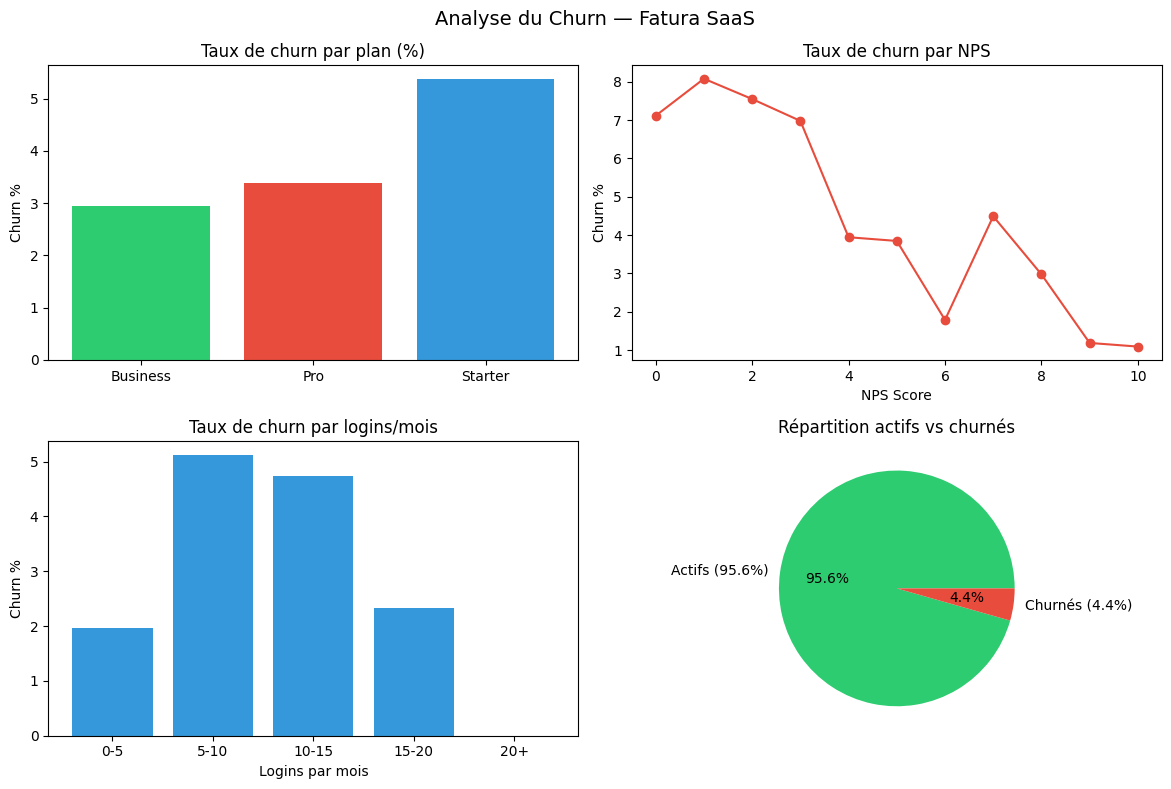

In [3]:
# QUESTION 3 — Quels sont les patterns de churn ?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Analyse du Churn — Fatura SaaS', fontsize=14)

# Graphique 1 — Churn par plan
churn_plan = df.groupby('plan')['churn'].mean() * 100
axes[0,0].bar(churn_plan.index, churn_plan.values,
              color=['#2ecc71','#e74c3c','#3498db'])
axes[0,0].set_title('Taux de churn par plan (%)')
axes[0,0].set_ylabel('Churn %')

# Graphique 2 — Churn vs NPS
churn_nps = df.groupby('nps_score')['churn'].mean() * 100
axes[0,1].plot(churn_nps.index, churn_nps.values,
               marker='o', color='#e74c3c')
axes[0,1].set_title('Taux de churn par NPS')
axes[0,1].set_xlabel('NPS Score')
axes[0,1].set_ylabel('Churn %')

# Graphique 3 — Churn vs Logins
df['login_groupe'] = pd.cut(df['logins_mois'],
                     bins=[0,5,10,15,20,30],
                     labels=['0-5','5-10','10-15','15-20','20+'])
churn_logins = df.groupby('login_groupe')['churn'].mean() * 100
axes[1,0].bar(churn_logins.index, churn_logins.values,
              color='#3498db')
axes[1,0].set_title('Taux de churn par logins/mois')
axes[1,0].set_xlabel('Logins par mois')
axes[1,0].set_ylabel('Churn %')

# Graphique 4 — Distribution churn actif vs churné
churn_counts = df['churn'].value_counts()
axes[1,1].pie(churn_counts.values,
              labels=['Actifs (95.6%)', 'Churnés (4.4%)'],
              colors=['#2ecc71','#e74c3c'],
              autopct='%1.1f%%')
axes[1,1].set_title('Répartition actifs vs churnés')

plt.tight_layout()
plt.show()

train/test

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copie du dataset
df_ml = df.copy()

# Encoder la variable texte "plan" en chiffres
# Starter=0, Pro=1, Business=2
le = LabelEncoder()
df_ml['plan_encode'] = le.fit_transform(df_ml['plan'])
print("Encodage plan :")
print(df[['plan']].drop_duplicates()
      .assign(plan_encode=le.transform(
          df[['plan']].drop_duplicates()['plan']))
      .sort_values('plan_encode'))

# Définir X (features) et y (cible)
X = df_ml[['plan_encode', 'arpu_tnd', 'anciennete_mois',
           'logins_mois', 'features_utilisees',
           'tickets_support', 'nps_score']]
y = df_ml['churn']

# Train / Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"\n✅ Données prêtes !")
print(f"Train : {X_train.shape[0]} clients (80%)")
print(f"Test  : {X_test.shape[0]} clients (20%)")
print(f"\nVariables X : {X.columns.tolist()}")
print(f"Variable y  : churn (0 ou 1)")

Encodage plan :
       plan  plan_encode
1  Business            0
2       Pro            1
0   Starter            2

✅ Données prêtes !
Train : 2306 clients (80%)
Test  : 577 clients (20%)

Variables X : ['plan_encode', 'arpu_tnd', 'anciennete_mois', 'logins_mois', 'features_utilisees', 'tickets_support', 'nps_score']
Variable y  : churn (0 ou 1)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)

# MODÈLE 1 — Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

# MODÈLE 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("=" * 45)
print("MODÈLE 1 — Logistic Regression")
print("=" * 45)
print(classification_report(y_test, y_pred_lr))
print(f"AUC Score : {auc_lr:.3f}")

print("=" * 45)
print("MODÈLE 2 — Random Forest")
print("=" * 45)
print(classification_report(y_test, y_pred_rf))
print(f"AUC Score : {auc_rf:.3f}")

MODÈLE 1 — Logistic Regression
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       551
           1       0.00      0.00      0.00        26

    accuracy                           0.95       577
   macro avg       0.48      0.50      0.49       577
weighted avg       0.91      0.95      0.93       577

AUC Score : 0.654
MODÈLE 2 — Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       551
           1       0.00      0.00      0.00        26

    accuracy                           0.95       577
   macro avg       0.48      0.50      0.49       577
weighted avg       0.91      0.95      0.93       577

AUC Score : 0.491


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

SMOTE

In [6]:
# Installer la librairie
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

# Avant équilibrage
print("AVANT équilibrage :")
print(f"Actifs   : {sum(y_train==0)}")
print(f"Churnés  : {sum(y_train==1)}")

# Appliquer SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Après équilibrage
print("\nAPRÈS équilibrage (SMOTE) :")
print(f"Actifs   : {sum(y_train_bal==0)}")
print(f"Churnés  : {sum(y_train_bal==1)}")
print(f"\n✅ Classes équilibrées !")

AVANT équilibrage :
Actifs   : 2205
Churnés  : 101

APRÈS équilibrage (SMOTE) :
Actifs   : 2205
Churnés  : 2205

✅ Classes équilibrées !


In [8]:
# MODÈLE 1 — Logistic Regression avec données équilibrées
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test)
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

# MODÈLE 2 — Random Forest avec données équilibrées
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("=" * 45)
print("MODÈLE 1 — Logistic Regression")
print("=" * 45)
print(classification_report(y_test, y_pred_lr,
      target_names=['Actif','Churné']))
print(f"AUC Score : {auc_lr:.3f}")

print("=" * 45)
print("MODÈLE 2 — Random Forest")
print("=" * 45)
print(classification_report(y_test, y_pred_rf,
      target_names=['Actif','Churné']))
print(f"AUC Score : {auc_rf:.3f}")

MODÈLE 1 — Logistic Regression
              precision    recall  f1-score   support

       Actif       0.97      0.72      0.83       551
      Churné       0.08      0.54      0.15        26

    accuracy                           0.72       577
   macro avg       0.53      0.63      0.49       577
weighted avg       0.93      0.72      0.80       577

AUC Score : 0.684
MODÈLE 2 — Random Forest
              precision    recall  f1-score   support

       Actif       0.96      0.94      0.95       551
      Churné       0.08      0.12      0.10        26

    accuracy                           0.90       577
   macro avg       0.52      0.53      0.52       577
weighted avg       0.92      0.90      0.91       577

AUC Score : 0.659


RANDOM FOREST — Seuil 30%
              precision    recall  f1-score   support

       Actif       0.96      0.83      0.89       551
      Churné       0.07      0.27      0.11        26

    accuracy                           0.81       577
   macro avg       0.52      0.55      0.50       577
weighted avg       0.92      0.81      0.86       577

AUC Score : 0.659


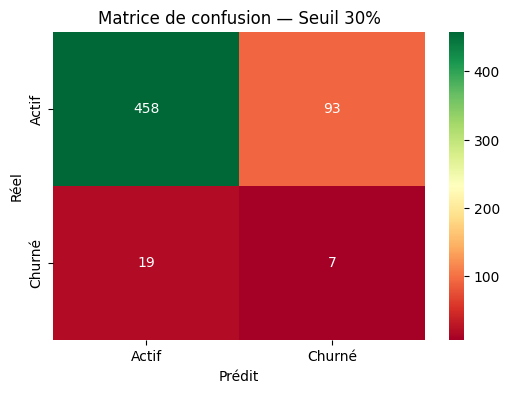

In [9]:
# Ajuster le seuil de décision
seuil = 0.30

# Probabilités prédites par Random Forest
y_proba_rf = rf.predict_proba(X_test)[:,1]

# Nouvelle prédiction avec seuil 30%
y_pred_seuil = (y_proba_rf >= seuil).astype(int)

print("=" * 45)
print("RANDOM FOREST — Seuil 30%")
print("=" * 45)
print(classification_report(y_test, y_pred_seuil,
      target_names=['Actif','Churné']))
print(f"AUC Score : {auc_rf:.3f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_seuil)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Actif','Churné'],
            yticklabels=['Actif','Churné'])
plt.title('Matrice de confusion — Seuil 30%')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

l'interpretation business

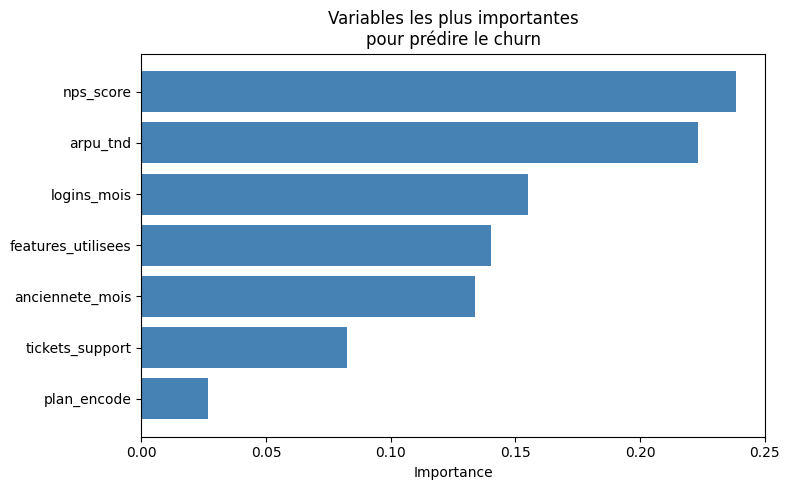


Classement des variables :
          variable  importance
         nps_score    0.238327
          arpu_tnd    0.223330
       logins_mois    0.155035
features_utilisees    0.140233
   anciennete_mois    0.133769
   tickets_support    0.082567
       plan_encode    0.026740


In [10]:
# Quelles variables expliquent le mieux le churn ?
importances = pd.DataFrame({
    'variable': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importances['variable'],
         importances['importance'],
         color='steelblue')
plt.title('Variables les plus importantes\npour prédire le churn')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nClassement des variables :")
print(importances.sort_values(
    'importance', ascending=False)
    .to_string(index=False))

In [11]:
print("""
RECOMMANDATIONS BUSINESS — Fatura SaaS
=======================================

1. NPS est le signal le plus fort (22.8%)
   → Action : Envoyer un sondage NPS automatique
     à J+30 après l'inscription
   → Si NPS < 4 : déclencher une alerte
     pour l'équipe Customer Success
   → Objectif : détecter les clients à risque
     avant qu'ils partent

2. ARPU prédit le churn (22.3%)
   → Action : Les clients Starter (29 TND)
     sont les plus à risque
   → Stratégie : Offrir une période d'essai
     gratuite du plan Pro pour les Starter
     actifs depuis 3 mois
   → Objectif : Upsell + réduction du churn

3. Logins faibles = danger (15.5%)
   → Action : Déclencher un email automatique
     si un client n'a pas eu de login
     depuis 7 jours
   → Message : "On a remarqué que vous
     n'avez pas utilisé Fatura cette semaine
     — voici 3 fonctionnalités que vous
     n'avez pas encore explorées"
   → Objectif : Réengager avant le churn

4. Adoption features (14%)
   → Action : Créer un onboarding guidé
     pour les 3 premières semaines
   → Objectif : Amener chaque client
     à utiliser au moins 5 features
     dans le premier mois

IMPACT ESTIMÉ :
Si ces 4 actions réduisent le churn de 4.4% à 2.5%
→ LTV augmente de 76%
→ Sur 2883 clients : +52 clients retenus/mois
→ Revenu supplémentaire : +52 × 68 TND = +3 536 TND/mois
""")


RECOMMANDATIONS BUSINESS — Fatura SaaS

1. NPS est le signal le plus fort (22.8%)
   → Action : Envoyer un sondage NPS automatique
     à J+30 après l'inscription
   → Si NPS < 4 : déclencher une alerte 
     pour l'équipe Customer Success
   → Objectif : détecter les clients à risque
     avant qu'ils partent

2. ARPU prédit le churn (22.3%)
   → Action : Les clients Starter (29 TND)
     sont les plus à risque
   → Stratégie : Offrir une période d'essai
     gratuite du plan Pro pour les Starter
     actifs depuis 3 mois
   → Objectif : Upsell + réduction du churn

3. Logins faibles = danger (15.5%)
   → Action : Déclencher un email automatique
     si un client n'a pas eu de login
     depuis 7 jours
   → Message : "On a remarqué que vous 
     n'avez pas utilisé Fatura cette semaine
     — voici 3 fonctionnalités que vous
     n'avez pas encore explorées"
   → Objectif : Réengager avant le churn

4. Adoption features (14%)
   → Action : Créer un onboarding guidé
     pour les 3 pr